# The sequencer

Streams in and out, a controller between, and a test stand in miniature: a table of setpoints with limits, jumps, init and cleanup.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

## 2 The streams

An array of IO nodes, discovered; the first board's offer comes first - every module's channels, ins with units, outs with ranges - and every number is a float.

In [2]:
from motor.pmsm import RAD_S_PER_RPM
from machine import ansi
from machine.nodes import Nodes
from machine.parts import Gain
from machine.wiring import diagram, feedback

nodes = Nodes.discover(port=PORT, simulated=SIMULATED, peripherals=())
node = nodes.of_type('bldc_inverter')[0]
drive, gates = node.rig.drive, node.rig.gates
drive.configure(source='model')
drive.model.configure(j=2e-5, b=1e-5, load=0.0, noise=0.05)
gates.on(bypass_sto=True, ignore_interlock=True)
print(Nodes([node]).card('drive', 'angle', keys=('omega_hat', 'iq', 'degrees', 'iq_ref', 'theta')))
print('%d channels on %d nodes, each over %s'
      % (len(nodes.capabilities()), len(nodes), ', '.join(node.modules)))

AX_1: bldc_inverter coaxial_63100, AX unit 1
  in  drive.iq A, drive.omega_hat rad/s, angle.degrees deg
  out drive.iq_ref A -5..5, drive.theta rad
1860 channels on 20 nodes, each over drive, angle, imu, thermal, power


## 3 The controller

`motion.velocity(2.0)` holds a `Loop` of one feedback, `speed`, clamped at 2 A; its slew set to 3000 rpm/s. Two gains put it in rpm: `rpm_target` in, `rpm` out.

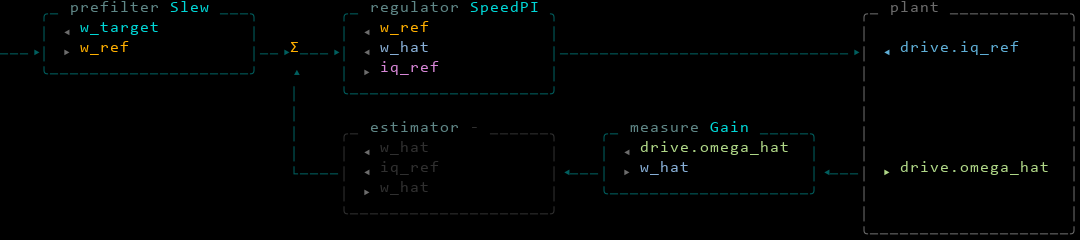

In [3]:
loop = node.rig.motion.velocity(2.0).loop
loop.parts['speed/prefilter'].configure(rate=3000 * RAD_S_PER_RPM)
loop.plug('rpm_in', Gain(RAD_S_PER_RPM), x='rpm_target', y='w_target')
loop.plug('rpm_out', Gain(1.0 / RAD_S_PER_RPM), x='w_hat', y='rpm')
ansi.image(feedback(loop, 'speed'))

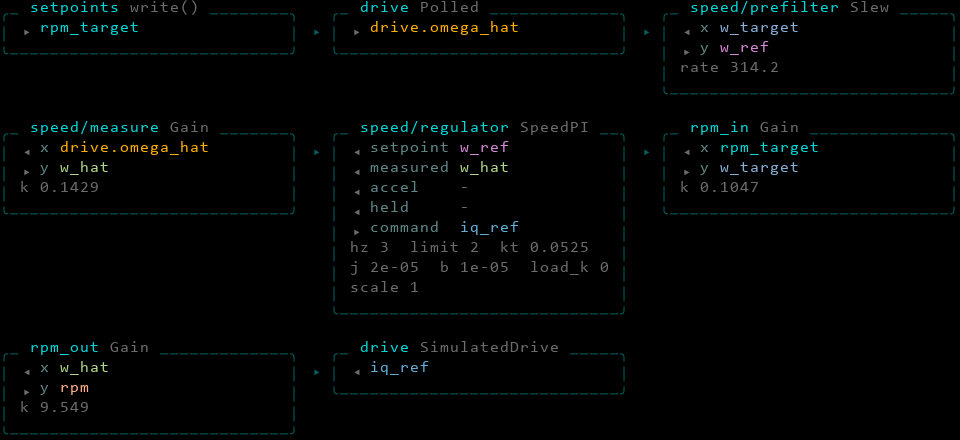

In [4]:
ansi.image(diagram(loop))

## 4 A sequence from a table

`init` rows first, `cleanup` rows last - always; `rpm.H` and `rpm.L` end a step when reached, `goto` jumps; the limits trip the whole run. `init` and `cleanup` hooks enter and leave the drive's mode.

In [5]:
import os
import tempfile
from machine.sequencer import Sequencer

TABLE = """group,seconds,label,rpm_target,rpm.H,rpm.L,goto,times
init,0.5,,0,,,,
,3,up,1500,1450,,,
,1.5,hold,1500,,,,
,3,down,500,,550,,
,1,,500,,,up,1
cleanup,2,,0,,,,
"""
folder = tempfile.mkdtemp()
path = os.path.join(folder, 'steps.csv')
with open(path, 'w', encoding='utf-8') as handle:
    handle.write(TABLE)

def arm(loop):
    drive.write(id_ref=0.0, iq_ref=0.0)
    drive.on('sensorless')

def disarm(loop):
    drive.off()

seq = Sequencer.read(path, limits={'iq_ref': {'HH': 1.9, 'LL': -1.9}}, init=arm, cleanup=disarm)
for steps in seq.groups.values():
    for step in steps:
        print(step)

<init 0.5 s set {'rpm_target': 0.0}>
<main up: 3 s set {'rpm_target': 1500.0} levels {'rpm': {'H': 1450.0}}>
<main hold: 1.5 s set {'rpm_target': 1500.0}>
<main down: 3 s set {'rpm_target': 500.0} levels {'rpm': {'L': 550.0}}>
<main 1 s set {'rpm_target': 500.0} goto up x1>
<cleanup 2 s set {'rpm_target': 0.0}>


## 5 Run it

In [6]:
out = seq.run(loop)
print('%s after %.1f s' % (out.status, out.rows[-1]['t'] - out.rows[0]['t']))
for row, label, ended, seconds in out.steps:
    print('row %d %-5s %5.2f s  %s' % (row, label or '', seconds, ended))

done after 9.0 s
row 0        0.49 s  time
row 1 up     0.53 s  rpm 1493 past H 1450
row 2 hold   1.47 s  time
row 3 down   0.37 s  rpm 434.6 past L 550
row 4        0.98 s  time
row 1 up     0.37 s  rpm 1510 past H 1450
row 2 hold   1.46 s  time
row 3 down   0.37 s  rpm 438.4 past L 550
row 4        0.98 s  time
row 5        1.99 s  time


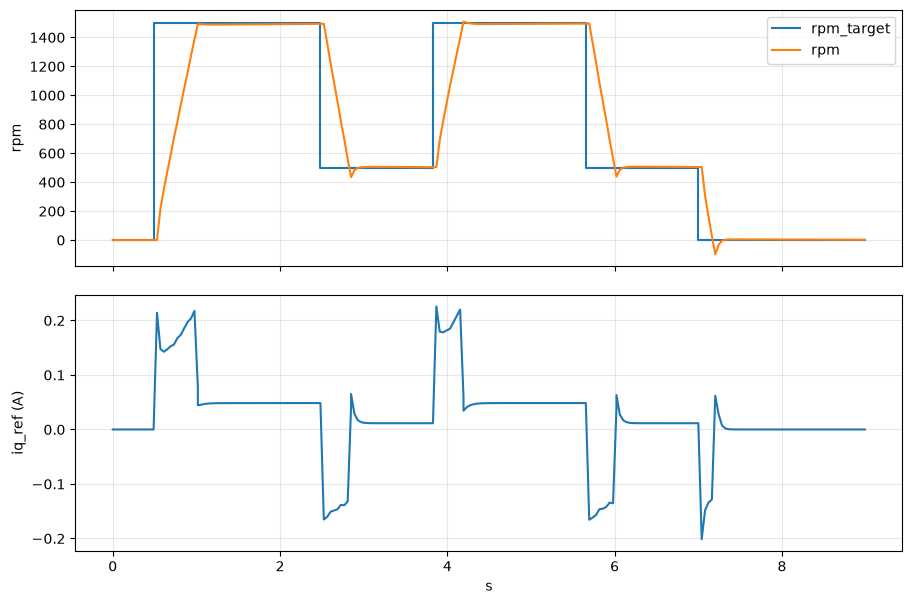

In [7]:
import pandas
from coaxial.draw.figures import figure, show

frame = pandas.DataFrame(out.rows).set_index('t')
fig, (top, bottom) = figure(rows=2, sharex=True)
top.plot(frame.index, frame['rpm_target'], label='rpm_target')
top.plot(frame.index, frame['rpm'], label='rpm')
top.set_ylabel('rpm')
top.legend(loc='upper right')
bottom.plot(frame.index, frame['iq_ref'])
bottom.set_ylabel('iq_ref (A)')
bottom.set_xlabel('s')
show(fig)

## 6 A program, not only a table

`n+` adds to a counter; a zero-second row with `n.L` decides - `then` when reached, `else` when not. Five stairs of 300 rpm, counted down: counters, adding and a branch make any program a table, and a model writes tables.

In [8]:
PROGRAM = """group,seconds,label,rpm_target,rpm_target+,n,n+,n.L,then,else
,0,,0,,5,,,,
,1,stair,,300,,,,,
,0,,,,,-1,0,stop,stair
cleanup,1.5,,0,,,,,,
"""
stairs = Sequencer.parse(PROGRAM, init=arm, cleanup=disarm)
climbed = stairs.run(loop)
tops = [r['rpm'] for r, nxt in zip(climbed.rows, climbed.rows[1:]) if nxt['step'] != r['step']
        and r['step'] == 1]
print('%s: %d stairs, rpm at the top of each: %s'
      % (climbed.status, len(tops), ', '.join('%.0f' % v for v in tops)))

done: 5 stairs, rpm at the top of each: 301, 600, 898, 1196, 1493


## 7 A trip

HH on `rpm` below what the step asks: the run trips at the limit and cleanup still brings the rotor home.

In [9]:
hot = Sequencer([{'seconds': 3, 'rpm_target': 3000},
                 {'group': 'cleanup', 'seconds': 2, 'rpm_target': 0}],
                limits={'rpm': {'HH': 2000}}, init=arm, cleanup=disarm)
tripped = hot.run(loop)
print(tripped.status, '-', tripped.reason)
print('then cleanup: row %d, %.2f s, rpm %.0f at the end'
      % (tripped.steps[-1][0], tripped.steps[-1][3], tripped.rows[-1]['rpm']))

tripped - rpm 2034 past HH 2000
then cleanup: row 1, 1.99 s, rpm 4 at the end


## 8 The same from Excel, twice

An .xlsx reads as the csv does; `cycles` repeats the main group.

In [10]:
xlsx = os.path.join(folder, 'steps.xlsx')
pandas.read_csv(path).to_excel(xlsx, index=False)
twice = Sequencer.read(xlsx, cycles=2, init=arm, cleanup=disarm)
same = ([repr(s) for g in twice.groups.values() for s in g]
        == [repr(s) for g in seq.groups.values() for s in g])
again = twice.run(loop)
print('xlsx rows as the csv: %s; %s, %d steps' % (same, again.status, len(again.steps)))
gates.off()
print('back on the converters:', drive.configure(source='adc')['source'])
nodes.close()

xlsx rows as the csv: True; done, 18 steps
back on the converters: True


## 9 Results

In [11]:
up = [s for s in out.steps if s[1] == 'up']
print('1. the table          %s, %d steps, %.1f s' % (out.status, len(out.steps),
                                                     sum(s[3] for s in out.steps)))
print('2. up ends on rpm.H   %s' % ', '.join('%.2f s' % s[3] for s in up))
print('3. the trip           %s' % tripped.reason)
print('4. excel, twice       %s, %d steps' % (again.status, len(again.steps)))

1. the table          done, 10 steps, 9.0 s
2. up ends on rpm.H   0.53 s, 0.37 s
3. the trip           rpm 2034 past HH 2000
4. excel, twice       done, 18 steps


- Streams, a controller, a sequence: each a layer with its own verbs.
- Cleanup runs however a run ends: done, tripped, or an exception.

**Bench.** Commission the record first; `init` arms, `cleanup` disarms; HH and LL on the currents the stage may carry.

## References

* `host/machine/sequencer.py` - `Sequencer`: rows, groups, jumps, limits, `run`
* `host/machine/controller.py` - `Loop`, `Feedback`: the controller it drives
* `host/coaxial/control/motion.py` - `Velocity`: the loop behind `motion.velocity`
* `host/tests/test_controller.py` - the sequencer against a toy rotor